<a href="https://colab.research.google.com/github/ykirpichev/moe/blob/develop/Compare_MoE_and_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!pip install megablocks[gg]
!pip install git+https://github.com/microsoft/tutel@main

  Cloning https://github.com/microsoft/tutel (to revision main) to /tmp/pip-req-build-_ebu3ftp
  Running command git clone --filter=blob:none --quiet https://github.com/microsoft/tutel /tmp/pip-req-build-_ebu3ftp
  Resolved https://github.com/microsoft/tutel to commit 69290452b4d4a1a1d76c221f4d332600367604fc
  Preparing metadata (setup.py) ... done
  Created wheel for tutel: filename=tutel-0.4-cp312-cp312-linux_x86_64.whl size=5771068 sha256=0b5339a2c262c0707c7873d51247ed847217f7af3e927d9d2f679687cbfee3c0
  Stored in directory: /tmp/pip-ephem-wheel-cache-hjnhgtg3/wheels/93/fc/48/fb7817270245f7a6651dc3e8bf1fd6d4b5d4ab84038e58e919
Successfully built tutel


In [57]:
import torch
import time
import os
import torch.distributed as dist
from megablocks import layers
from tutel import moe as tutel_moe

# Initialize Distributed Environment (Required for Tutel)
if not dist.is_initialized():
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'
    dist.init_process_group(backend='nccl', init_method='env://', rank=0, world_size=1)

# Configuration
BATCH_SIZE = 32
SEQ_LEN = 2048
HIDDEN_SIZE = 768  # Set to GPT-2 equivalent
FFN_HIDDEN_SIZE = 3072  # 4x HIDDEN_SIZE for Dense MLP
NUM_EXPERTS = 8          # Total experts in MoE (as requested)
MOE_FFN_HIDDEN_SIZE = 768 # Adjusted FFN hidden size for each MoE expert
TOP_K = 2                # Active experts per token

device = torch.cuda.current_device()
dtype_dense = torch.float32 # FP32 precision for Dense MLP
dtype_moe = torch.bfloat16 # BF16 precision for MegaBlocks MoE
dtype_tutel = torch.float32 # FP32 precision for Tutel (as per snippet)

# 1. Setup Dense MLP (Baseline)
dense_mlp = torch.nn.Sequential(
    torch.nn.Linear(HIDDEN_SIZE, FFN_HIDDEN_SIZE, bias=False),
    torch.nn.GELU(),
    torch.nn.Linear(FFN_HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
).to(device).to(dtype_dense)

# 2. Setup MegaBlocks dMoE
moe_args = layers.arguments.Arguments(
    hidden_size=HIDDEN_SIZE,
    ffn_hidden_size=MOE_FFN_HIDDEN_SIZE,
    moe_num_experts=NUM_EXPERTS,
    moe_top_k=TOP_K,
    device=device,
    fp16=False,
    bf16=True, # MegaBlocks using BF16
    mlp_impl="grouped"
)
moe_layer = layers.dmoe.dMoE(moe_args).to(device).to(dtype_moe)

# 3. Setup Tutel MoE
tutel_layer = tutel_moe.moe_layer(
    gate_type={'type': 'top', 'k': TOP_K},
    model_dim=HIDDEN_SIZE,
    experts={
        'count_per_node': NUM_EXPERTS,
        'type': 'ffn',
        'hidden_size_per_expert': MOE_FFN_HIDDEN_SIZE,
        'activation_fn': lambda x: torch.nn.functional.gelu(x), # Using GELU to match others
    }
).to(device).to(dtype_tutel)

# Mock Inputs
x_dense_fwd = torch.randn(BATCH_SIZE * SEQ_LEN, HIDDEN_SIZE, device=device, dtype=dtype_dense)
x_moe_fwd = torch.randn(BATCH_SIZE * SEQ_LEN, HIDDEN_SIZE, device=device, dtype=dtype_moe)
x_tutel_fwd = torch.randn(BATCH_SIZE * SEQ_LEN, HIDDEN_SIZE, device=device, dtype=dtype_tutel)

x_dense_bwd = torch.randn(BATCH_SIZE * SEQ_LEN, HIDDEN_SIZE, device=device, dtype=dtype_dense, requires_grad=True)
x_moe_bwd = torch.randn(BATCH_SIZE * SEQ_LEN, HIDDEN_SIZE, device=device, dtype=dtype_moe, requires_grad=True)
x_tutel_bwd = torch.randn(BATCH_SIZE * SEQ_LEN, HIDDEN_SIZE, device=device, dtype=dtype_tutel, requires_grad=True)

def benchmark(label, model, input_data, iterations=100, is_backward=False):
    # Warmup
    for _ in range(10):
        if is_backward:
            output = model(input_data)
            if isinstance(output, tuple):
                output = output[0]
            output.sum().backward()
            model.zero_grad()
            if input_data.grad is not None:
                input_data.grad.zero_()
        else:
            _ = model(input_data)
    torch.cuda.synchronize()

    start = time.time()
    for _ in range(iterations):
        if is_backward:
            output = model(input_data)
            if isinstance(output, tuple):
                output = output[0]
            output.sum().backward()
            model.zero_grad()
            if input_data.grad is not None:
                input_data.grad.zero_()
        else:
            _ = model(input_data)
    torch.cuda.synchronize()
    end = time.time()

    avg_time = (end - start) / iterations
    tps = (BATCH_SIZE * SEQ_LEN) / avg_time
    pass_type = "Fwd+Bwd" if is_backward else "Fwd Only"
    print(f"{label} ({pass_type}): {avg_time*1000:.2f} ms | Throughput: {tps:.2f} tokens/sec")
    return tps

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model, dtype):
    num_params = count_parameters(model)
    if dtype == torch.float32:
        bytes_per_param = 4
    elif dtype == torch.bfloat16:
        bytes_per_param = 2
    else:
        bytes_per_param = model.parameters().__next__().element_size()
    return (num_params * bytes_per_param) / (1024 * 1024)

print(f"--- H100 Benchmark (Hidden: {HIDDEN_SIZE}, Experts: {NUM_EXPERTS}) ---")
dense_fwd_tps = benchmark("Dense MLP  ", dense_mlp, x_dense_fwd, is_backward=False)
moe_fwd_tps = benchmark("MegaBlocks MoE", moe_layer, x_moe_fwd, is_backward=False)
tutel_fwd_tps = benchmark("Tutel MoE   ", tutel_layer, x_tutel_fwd, is_backward=False)

dense_bwd_tps = benchmark("Dense MLP  ", dense_mlp, x_dense_bwd, is_backward=True)
moe_bwd_tps = benchmark("MegaBlocks MoE", moe_layer, x_moe_bwd, is_backward=True)
tutel_bwd_tps = benchmark("Tutel MoE   ", tutel_layer, x_tutel_bwd, is_backward=True)

print("\n--- Speedup (vs Dense MLP) ---")
if dense_fwd_tps > 0:
    print(f"Fwd Only - MegaBlocks: {moe_fwd_tps / dense_fwd_tps:.2f}x")
    print(f"Fwd Only - Tutel:      {tutel_fwd_tps / dense_fwd_tps:.2f}x")

if dense_bwd_tps > 0:
    print(f"Fwd+Bwd - MegaBlocks:  {moe_bwd_tps / dense_bwd_tps:.2f}x")
    print(f"Fwd+Bwd - Tutel:       {tutel_bwd_tps / dense_bwd_tps:.2f}x")

print("\n--- Model Sizes ---")
print(f"Dense MLP Parameters: {count_parameters(dense_mlp) / 1e6:.2f} M")
print(f"MegaBlocks MoE Parameters: {count_parameters(moe_layer) / 1e6:.2f} M")
print(f"Tutel MoE Parameters: {count_parameters(tutel_layer) / 1e6:.2f} M")

print(f"Dense MLP Size: {get_model_size_mb(dense_mlp, dtype_dense):.2f} MB")
print(f"MegaBlocks MoE Size: {get_model_size_mb(moe_layer, dtype_moe):.2f} MB")
print(f"Tutel MoE Size: {get_model_size_mb(tutel_layer, dtype_tutel):.2f} MB")

--- H100 Benchmark (Hidden: 768, Experts: 8) ---
Dense MLP   (Fwd Only): 33.53 ms | Throughput: 1954572.53 tokens/sec
MegaBlocks MoE (Fwd Only): 3.17 ms | Throughput: 20689383.43 tokens/sec
Tutel MoE    (Fwd Only): 21.44 ms | Throughput: 3056538.92 tokens/sec
Dense MLP   (Fwd+Bwd): 103.27 ms | Throughput: 634596.97 tokens/sec
MegaBlocks MoE (Fwd+Bwd): 8.18 ms | Throughput: 8010549.10 tokens/sec
Tutel MoE    (Fwd+Bwd): 61.54 ms | Throughput: 1064937.45 tokens/sec

--- Speedup (vs Dense MLP) ---
Fwd Only - MegaBlocks: 10.59x
Fwd Only - Tutel:      1.56x
Fwd+Bwd - MegaBlocks:  12.62x
Fwd+Bwd - Tutel:       1.68x

--- Model Sizes ---
Dense MLP Parameters: 4.72 M
MegaBlocks MoE Parameters: 9.44 M
Tutel MoE Parameters: 9.46 M
Dense MLP Size: 18.00 MB
MegaBlocks MoE Size: 18.01 MB
Tutel MoE Size: 36.07 MB


# Task
Train a Dense MLP and a MegaBlocks MoE model on synthetic regression data, compare their training errors, and present the results.

## Prepare Synthetic Data

### Subtask:
Generate synthetic input and target data for a simple regression task, ensuring it is on the GPU and in `float32`.


In [61]:
num_samples = BATCH_SIZE * SEQ_LEN
input_features = HIDDEN_SIZE
output_features = 1

# Generate random input features X
X = torch.randn(num_samples, input_features, device=device, dtype=torch.float32)

# Generate target values y with a HARDER, NON-LINEAR relationship
# We project the first 32 features and apply a sine wave, making it harder for a simple linear layer to fit.
torch.manual_seed(42) # Ensure reproducibility for the target function
projection_weights = torch.randn(32, 1, device=device, dtype=torch.float32)
y = torch.sin(X[:, :32] @ projection_weights) + torch.randn(num_samples, 1, device=device, dtype=torch.float32) * 0.1

print(f"Generated X shape: {X.shape}, dtype: {X.dtype}, device: {X.device}")
print(f"Generated y shape: {y.shape}, dtype: {y.dtype}, device: {y.device}")

Generated X shape: torch.Size([65536, 768]), dtype: torch.float32, device: cuda:0
Generated y shape: torch.Size([65536, 1]), dtype: torch.float32, device: cuda:0


## Define Training and Evaluation Logic

### Subtask:
Create a function `train_and_evaluate` that takes a model, input data, target data, optimizer, loss function, and number of iterations. This function will perform a training loop, compute the loss, and return the final loss value.


In [59]:
import matplotlib.pyplot as plt

def train_and_evaluate(model, X, y, optimizer, loss_fn, iterations):
    model.train() # Set the model to training mode
    loss_history = []

    for i in range(iterations):
        optimizer.zero_grad() # Zero out the gradients

        # Forward pass
        predictions = model(X)
        # Handle cases where model might return a tuple (e.g., MoE models)
        if isinstance(predictions, tuple):
            predictions = predictions[0]

        # Calculate loss
        loss = loss_fn(predictions, y)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if (i + 1) % 100 == 0:
            print(f"Iteration {i+1}/{iterations}, Loss: {loss.item():.4f}")

    model.eval() # Set the model to evaluation mode
    return loss.item(), loss_history # Return the final loss and history

## Setup Models, Loss, and Optimizers

### Subtask:
Re-initialize the `dense_mlp` and `moe_layer` with the current configurations. Define `torch.nn.MSELoss` as the loss function and `torch.optim.Adam` for both models. Ensure appropriate data types are used for each model and its optimizer, especially accommodating `bfloat16` for the MegaBlocks MoE if required by its internal operations.


In [62]:
import torch
from megablocks import layers

# Wrapper to add regression head to the original MoE backbone
class MoERegressionWrapper(torch.nn.Module):
    def __init__(self, moe_args, hidden_size, output_features, device, dtype):
        super().__init__()
        self.dtype = dtype
        # Backbone: Same as benchmarked model (Preserves original size)
        self.backbone = layers.dmoe.dMoE(moe_args).to(device).to(dtype)
        # Regression Head: Small projection to scalar
        self.head = torch.nn.Linear(hidden_size, output_features).to(device).to(torch.float32)

    def forward(self, x):
        # Explicit input conversion
        x = x.to(self.dtype)
        # Backbone returns (output, auxiliary_loss)
        features, _ = self.backbone(x)
        out = self.head(features.to(torch.float32))
        # Explicit output conversion to float32
        return out.to(torch.float32)

# Wrapper to add regression head to the original Dense backbone
class DenseRegressionWrapper(torch.nn.Module):
    def __init__(self, hidden_size, ffn_hidden_size, output_features, device, dtype):
        super().__init__()
        self.dtype = dtype
        # Backbone: Same as benchmarked model (Preserves original size)
        self.backbone = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, ffn_hidden_size, bias=False),
            torch.nn.GELU(),
            torch.nn.Linear(ffn_hidden_size, hidden_size, bias=False)
        ).to(device).to(dtype)
        # Regression Head: Small projection to scalar
        self.head = torch.nn.Linear(hidden_size, output_features).to(device).to(dtype)

    def forward(self, x):
        # Explicit input conversion
        x = x.to(self.dtype)
        features = self.backbone(x)
        out = self.head(features)
        # Explicit output conversion to float32
        return out.to(torch.float32)

print("Model Wrappers defined. (Run the training cell to instantiate and train)")

Model Wrappers defined. (Run the training cell to instantiate and train)


## Run Training and Compare Errors

### Subtask:
Execute the `train_and_evaluate` function for both the Dense MLP and MegaBlocks MoE for 100 iterations. Print the final loss (error) for each model and a comparison.


--- Re-initializing Models ---
Models re-initialized.

--- Training Dense MLP ---
Iteration 100/200, Loss: 0.4820
Iteration 200/200, Loss: 0.0293

--- Training MegaBlocks MoE ---
Iteration 100/200, Loss: 0.0003
Iteration 200/200, Loss: 0.0000

--- Final Loss Comparison ---
Dense MLP Final Loss: 0.0293
MegaBlocks MoE Final Loss: 0.0000
The MegaBlocks MoE achieved a lower final loss by 0.0292.


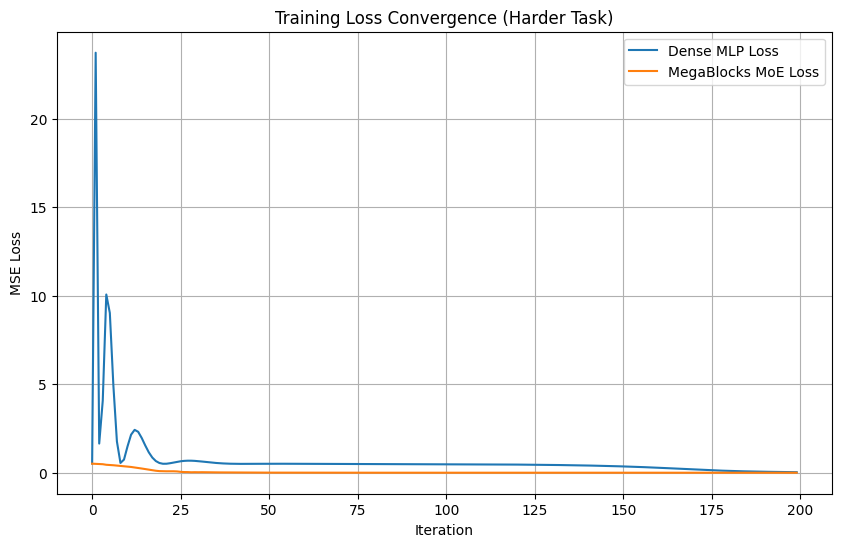

In [66]:
print("--- Re-initializing Models ---")
# 1. Initialize Dense Model
dense_train_model = DenseRegressionWrapper(HIDDEN_SIZE, FFN_HIDDEN_SIZE, 1, device, dtype_dense)

# 2. Initialize MoE Model
moe_train_model = MoERegressionWrapper(moe_args, HIDDEN_SIZE, 1, device, dtype_moe)

# 3. Loss and Optimizers
loss_fn = torch.nn.MSELoss()
optimizer_dense = torch.optim.Adam(dense_train_model.parameters(), lr=1e-3)
optimizer_moe = torch.optim.Adam(moe_train_model.parameters(), lr=1e-3)
print("Models re-initialized.")

print("\n--- Training Dense MLP ---")
dense_loss, dense_history = train_and_evaluate(dense_train_model, X, y, optimizer_dense, loss_fn, iterations=200)

print("\n--- Training MegaBlocks MoE ---")
# Input casting is now handled inside the model wrapper, so we pass X and y as float32
moe_loss, moe_history = train_and_evaluate(moe_train_model, X, y, optimizer_moe, loss_fn, iterations=200)

print("\n--- Final Loss Comparison ---")
print(f"Dense MLP Final Loss: {dense_loss:.4f}")
print(f"MegaBlocks MoE Final Loss: {moe_loss:.4f}")

if dense_loss < moe_loss:
    print(f"The Dense MLP achieved a lower final loss by {moe_loss - dense_loss:.4f}.")
elif moe_loss < dense_loss:
    print(f"The MegaBlocks MoE achieved a lower final loss by {dense_loss - moe_loss:.4f}.")
else:
    print("Both models achieved the same final loss.")

# Plot Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(dense_history, label='Dense MLP Loss')
plt.plot(moe_history, label='MegaBlocks MoE Loss')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Training Loss Convergence (Harder Task)')
plt.legend()
plt.grid(True)
plt.show()